In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import StratifiedTable

In [119]:
# Load the files
metadata = pd.read_csv('../../old/Final_65.csv')
plasmid_wide = pd.read_csv('plasmidfinder_replicons_wide.tsv', sep='\t')
plasmid_long = pd.read_csv('plasmidfinder_replicons_long.tsv', sep='\t')
plasmid_summary = pd.read_csv('plasmidfinder_summary.tsv', sep='\t')

In [121]:
# Check removed isolate
removed_id = 'GCA_037003325.1'
removed_info = metadata[metadata['Assembly'] == removed_id]
print("\nRemoved Isolate Info:")
print(removed_info[['Assembly', 'is_LMF', 'SNP cluster']])


Removed Isolate Info:
           Assembly  is_LMF      SNP cluster
57  GCA_037003325.1       0  PDS000026945.72


In [123]:
# Filter
filtered_metadata = metadata[metadata['Assembly'] != removed_id].copy()
print(f"\nTotal after filtering: {len(filtered_metadata)}")


Total after filtering: 64


In [125]:
# Re-calculate Cohort Totals
cohort_counts = filtered_metadata.groupby('is_LMF').size()
print("\nNew Cohort Counts (0=Control, 1=LMF):")
print(cohort_counts)


New Cohort Counts (0=Control, 1=LMF):
is_LMF
0    40
1    24
dtype: int64


In [127]:
# Load plasmid data
plasmid_wide = pd.read_csv('plasmidfinder_replicons_wide.tsv', sep='\t')
df = pd.merge(filtered_metadata, plasmid_wide, left_on='Assembly', right_on='Sample', how='left')
plasmid_cols = ['IncFIB(S)', 'IncFII(S)', 'IncX1', 'IncI1-I(Alpha)', 'IncI2(Delta)']
df[plasmid_cols] = df[plasmid_cols].fillna(0).astype(int)

In [129]:
# Check Overall Totals
print("\nOverall Plasmid Totals (n=64):")
print(df[plasmid_cols].sum())

# Check Totals by Cohort
print("\nPlasmid Totals by Cohort:")
print(df.groupby('is_LMF')[plasmid_cols].sum())


Overall Plasmid Totals (n=64):
IncFIB(S)         58
IncFII(S)         57
IncX1             14
IncI1-I(Alpha)     1
IncI2(Delta)       1
dtype: int64

Plasmid Totals by Cohort:
        IncFIB(S)  IncFII(S)  IncX1  IncI1-I(Alpha)  IncI2(Delta)
is_LMF                                                           
0              36         35     10               1             0
1              22         22      4               0             1


In [133]:
# Re-prepare df
df['Cohort'] = df['is_LMF'].map({1: 'LMF', 0: 'Control'})

# 1. Fisher's Exact Test with FDR
fisher_results = []
for p in plasmid_cols:
    table = pd.crosstab(df['Cohort'], df[p])
    # Ensure 2x2
    for val in [0, 1]:
        if val not in table.columns: table[val] = 0
    # table: rows=['Control', 'LMF'], cols=[0, 1]
    # format for fisher: [[a, b], [c, d]] where a=LMF_1, b=LMF_0, c=Ctrl_1, d=Ctrl_0
    c_tab = [[table.loc['LMF', 1], table.loc['LMF', 0]],
             [table.loc['Control', 1], table.loc['Control', 0]]]
    _, p_val = fisher_exact(c_tab)
    fisher_results.append({'Plasmid': p, 'p_raw': p_val})

f_df = pd.DataFrame(fisher_results)
f_df['p_fdr'] = multipletests(f_df['p_raw'], method='fdr_bh')[1]

# 2. CMH Test with FDR
cmh_results = []
# Restrict to mixed clusters
mixed_clusters = df.groupby('SNP cluster')['Cohort'].nunique()
valid_clusters = mixed_clusters[mixed_clusters == 2].index
sub_df = df[df['SNP cluster'].isin(valid_clusters)]

In [135]:
for p in plasmid_cols:
    tables = []
    # Count how many informative clusters
    informative_count = 0
    for cluster in valid_clusters:
        cluster_data = sub_df[sub_df['SNP cluster'] == cluster]
        # Skip if all same for this plasmid in this cluster
        if cluster_data[p].nunique() <= 1:
            continue
            
        informative_count += 1
        tab = pd.crosstab(cluster_data['Cohort'], cluster_data[p])
        for val in [0, 1]:
            if val not in tab.columns: tab[val] = 0
        for cohort in ['LMF', 'Control']:
            if cohort not in tab.index: tab.loc[cohort] = [0, 0]
        
        # Order: LMF (pos, neg), Control (pos, neg)
        tab_2x2 = tab.loc[['LMF', 'Control'], [1, 0]].values
        tables.append(tab_2x2)
    
    if len(tables) > 0:
        stratified_data = np.stack(tables, axis=2)
        st = StratifiedTable(stratified_data)
        cmh_results.append({
            'Plasmid': p,
            'cmh_p_raw': st.test_null_odds().pvalue,
            'OR_pooled': st.oddsratio_pooled,
            'Informative_Clusters': informative_count
        })
    else:
        cmh_results.append({
            'Plasmid': p,
            'cmh_p_raw': 1.0,
            'OR_pooled': np.nan,
            'Informative_Clusters': 0
        })

cmh_df = pd.DataFrame(cmh_results)
# FDR for CMH
cmh_df['cmh_p_fdr'] = multipletests(cmh_df['cmh_p_raw'], method='fdr_bh')[1]

print("Fisher Results:")
print(f_df)
print("\nCMH Results:")
print(cmh_df)

Fisher Results:
          Plasmid     p_raw  p_fdr
0       IncFIB(S)  1.000000    1.0
1       IncFII(S)  0.702240    1.0
2           IncX1  0.540842    1.0
3  IncI1-I(Alpha)  1.000000    1.0
4    IncI2(Delta)  0.375000    1.0

CMH Results:
          Plasmid  cmh_p_raw  OR_pooled  Informative_Clusters  cmh_p_fdr
0       IncFIB(S)   0.947933   0.925926                     4   0.947933
1       IncFII(S)   0.637644   1.592593                     5   0.797055
2           IncX1   0.611220   0.635294                     4   0.797055
3  IncI1-I(Alpha)   0.479500   0.000000                     1   0.797055
4    IncI2(Delta)   0.414216        inf                     1   0.797055


C:\Users\Kinley Tenzin\anaconda3\Lib\site-packages\statsmodels\stats\contingency_tables.py:1077: RuntimeWarning: divide by zero encountered in scalar divide
  odds_ratio = np.sum(self._ad / self._n) / np.sum(self._bc / self._n)


In [137]:
# Redo Figure 1: Heatmap
lmf_counts = df[df['Cohort'] == 'LMF'].groupby('SNP cluster').size()
high_tier_clusters = lmf_counts[lmf_counts >= 2].index.tolist()
df['is_high_tier'] = df['SNP cluster'].isin(high_tier_clusters)
df_sorted = df.sort_values(['is_high_tier', 'SNP cluster', 'Cohort'], ascending=[False, True, True]).reset_index(drop=True)

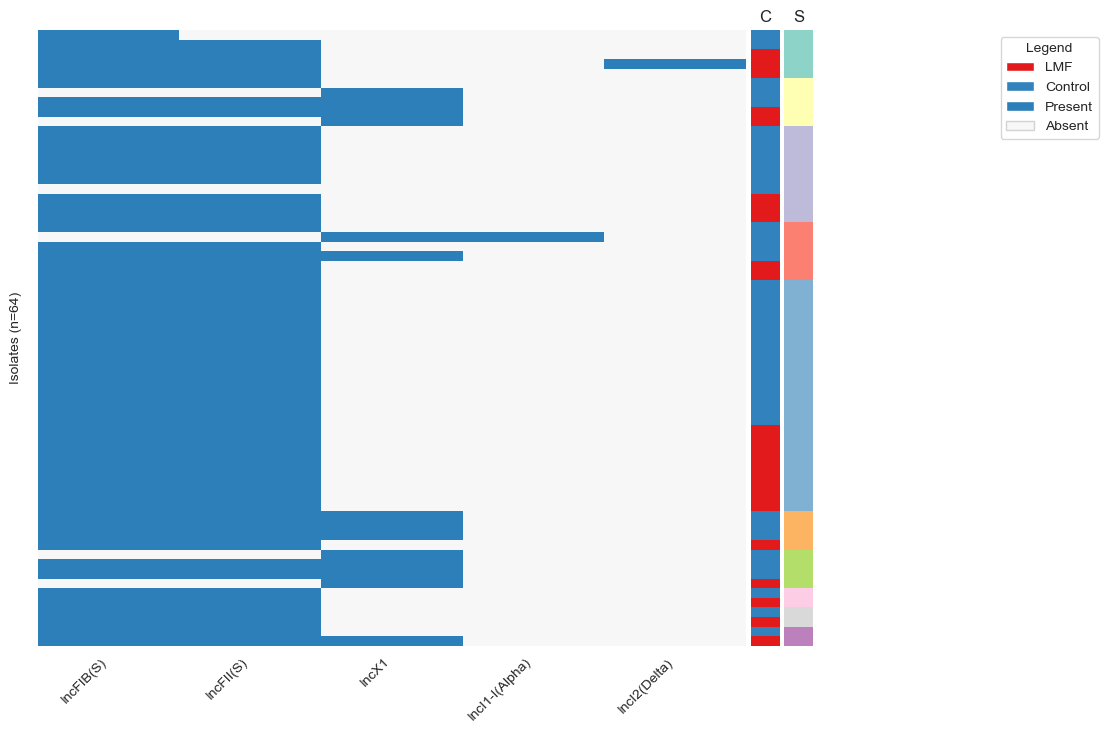

In [141]:
fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(10, 8), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.02})
presence_color = '#2c7fb8'
absence_color = '#f7f7f7'
cmap = mcolors.ListedColormap([absence_color, presence_color])
sns.heatmap(df_sorted[plasmid_cols], ax=ax_main, cmap=cmap, cbar=False, linewidths=0)
ax_main.set_yticklabels([])
ax_main.set_ylabel(f"Isolates (n={len(df_sorted)})")
ax_main.set_xticklabels(plasmid_cols, rotation=45, ha='right')

cohort_palette = {'LMF': '#e31a1c', 'Control': '#3182bd'}
cohort_rgb = [mcolors.to_rgb(cohort_palette[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cohort.axis('off')
ax_cohort.set_title("C")

cluster_ids, _ = pd.factorize(df_sorted['SNP cluster'])
cluster_palette = sns.color_palette("Set3", len(np.unique(cluster_ids)))
cluster_rgb = [cluster_palette[i] for i in cluster_ids]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto')
ax_cluster.axis('off')
ax_cluster.set_title("S")

legend_elements = [Patch(facecolor=cohort_palette['LMF'], label='LMF'), 
                   Patch(facecolor=cohort_palette['Control'], label='Control'),
                   Patch(facecolor=presence_color, label='Present'), 
                   Patch(facecolor=absence_color, label='Absent', edgecolor='lightgray')]
ax_main.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', title="Legend")

plt.savefig('Figure_1_Heatmap_Fixed.tiff', dpi=600, bbox_inches='tight')

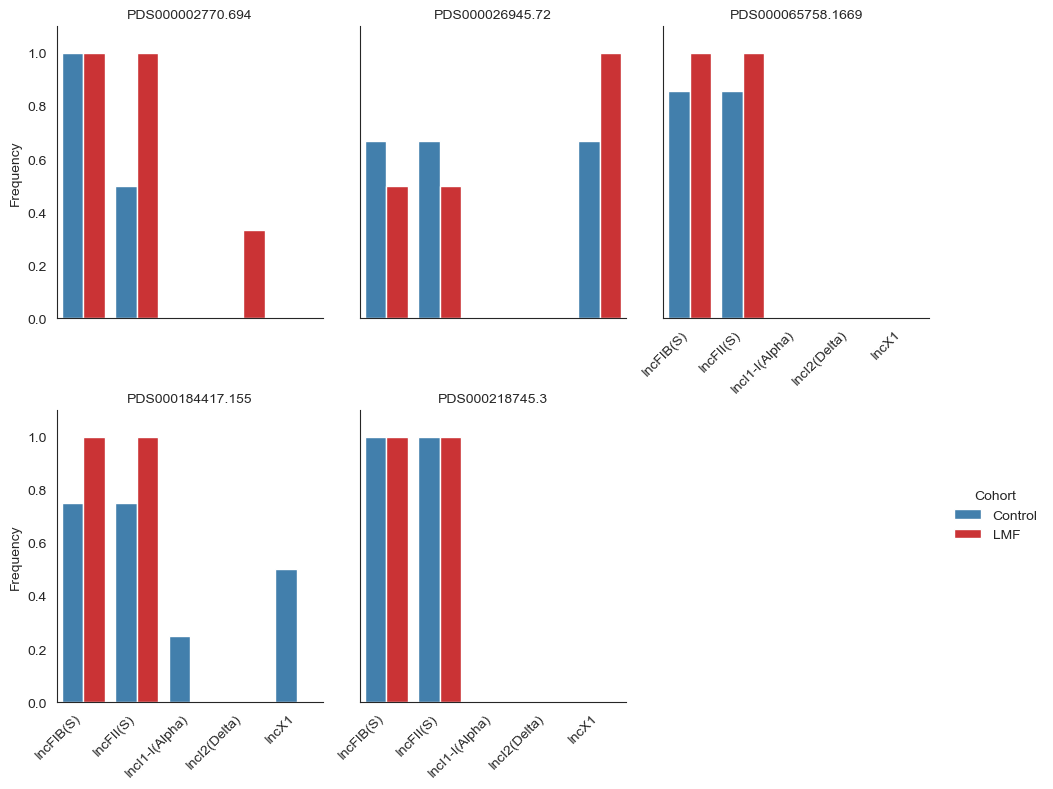

In [165]:
# Redo Figure 2: Intra-cluster frequency

sns.set_style("white")
ht_df = df[df['is_high_tier']].copy()
ht_melt = ht_df.melt(id_vars=['SNP cluster', 'Cohort'], value_vars=plasmid_cols, var_name='Plasmid', value_name='Presence')
cluster_prev = ht_melt.groupby(['SNP cluster', 'Cohort', 'Plasmid'])['Presence'].mean().reset_index()

g = sns.catplot(data=cluster_prev, x='Plasmid', y='Presence', hue='Cohort', col='SNP cluster', 
                kind='bar', palette=cohort_palette, height=4, aspect=0.8, col_wrap=3)
g.set_axis_labels("", "Frequency")
g.set_titles("{col_name}")
plt.ylim(0, 1.1)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
sns.move_legend(g, "lower right", bbox_to_anchor=(1, 0.3))
g.tight_layout()
plt.savefig('Figure_2_HighTierFrequency_Fixed.tiff', dpi=600, bbox_inches='tight')

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_17352\2842735605.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_ready = ht_alleles.groupby(['SNP cluster', 'Cohort', 'PlasmidFamily'])['RepliconAllele'].first().unstack(fill_value='-').applymap(lambda x: x.split('__')[0] if x != '-' else '-')


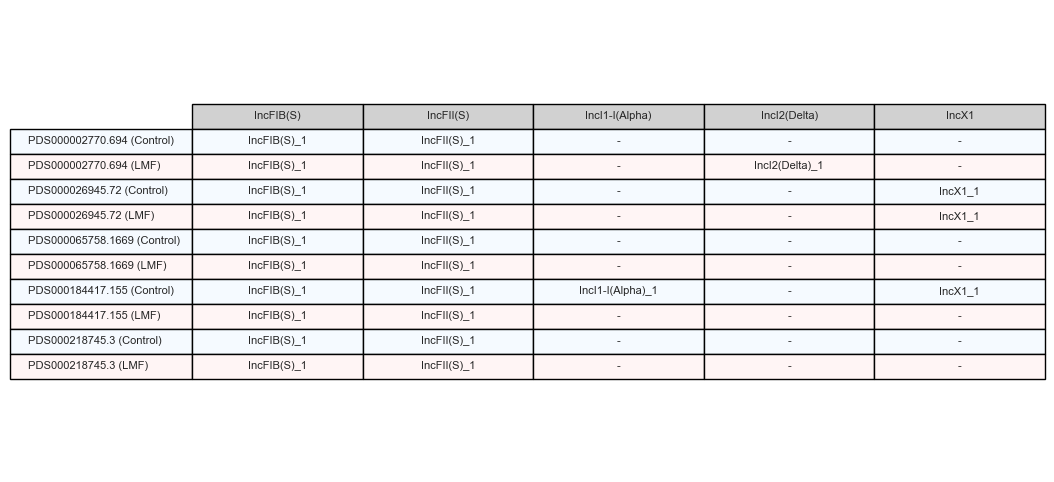

In [175]:
# Redo Figure 3: Allele Table
plasmid_long = pd.read_csv('plasmidfinder_replicons_long.tsv', sep='\t')
allele_data = pd.merge(plasmid_long, df[['Assembly', 'SNP cluster', 'Cohort']], left_on='Sample', right_on='Assembly')
ht_alleles = allele_data[allele_data['SNP cluster'].isin(high_tier_clusters)]
plot_ready = ht_alleles.groupby(['SNP cluster', 'Cohort', 'PlasmidFamily'])['RepliconAllele'].first().unstack(fill_value='-').applymap(lambda x: x.split('__')[0] if x != '-' else '-')

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
the_table = ax.table(cellText=plot_ready.values, 
                      rowLabels=[f"{idx[0]} ({idx[1]})" for idx in plot_ready.index], 
                      colLabels=plot_ready.columns, 
                      cellLoc='center', loc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(8)
the_table.scale(1.1, 1.5)
for (row, col), cell in the_table.get_celld().items():
    if row == 0: 
        cell.set_facecolor('#d1d1d1')
    elif row > 0: 
        lbl = the_table.get_celld()[(row, -1)].get_text().get_text()
        cell.set_facecolor('#fff5f5' if '(LMF)' in lbl else '#f5faff')
# plt.title("Conservation of Replicon Alleles in High-Tier SNP Clusters", pad=40)
plt.savefig('Figure_3_AlleleTable_Fixed.tiff', bbox_inches='tight', dpi=600)

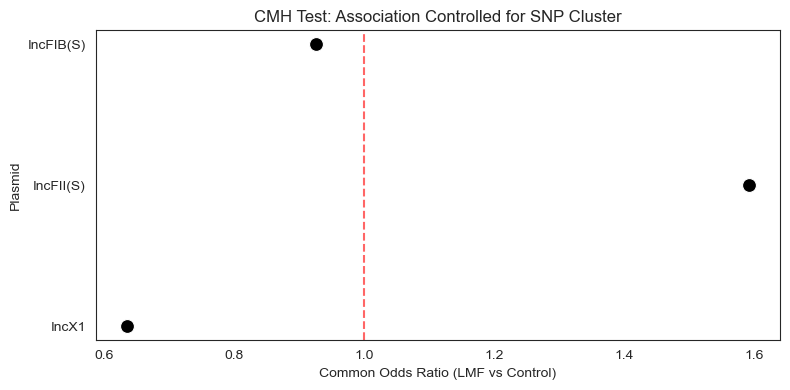

In [179]:
# Redo Forest Plot for CMH
plt.figure(figsize=(8, 4))
plot_cmh = cmh_df[cmh_df['OR_pooled'].notna() & (cmh_df['OR_pooled'] != np.inf) & (cmh_df['OR_pooled'] != 0)]
# Use points for OR
sns.scatterplot(data=plot_cmh, x='OR_pooled', y='Plasmid', color='black', s=100)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.6)
plt.xlabel('Common Odds Ratio (LMF vs Control)')
plt.title('CMH Test: Association Controlled for SNP Cluster')
plt.grid(False)
plt.tight_layout()
plt.savefig('Figure_4_CMH_Forest_Fixed.tiff', dpi=600, bbox_inches='tight')

In [181]:
# Save corrected stats to CSV
cmh_df.to_csv('Table_1_CMH_Corrected.csv', index=False)
f_df.to_csv('Table_2_Fisher_Corrected.csv', index=False)

In [15]:
# 1. Filter metadata to exclude the poor-quality assembly
filtered_metadata = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
print(f"Number of assemblies after filtering: {len(filtered_metadata)}")
merged_df = pd.merge(filtered_metadata, plasmid_wide, left_on='Assembly', right_on='Sample', how='left')

Number of assemblies after filtering: 64


In [19]:
# Fill NaN with 0 for plasmid presence columns (assuming if not in wide, it's 0)
plasmid_cols = [col for col in plasmid_wide.columns if col != 'Sample']
merged_df[plasmid_cols] = merged_df[plasmid_cols].fillna(0).astype(int)

In [23]:
# 3. Analyze prevalence by cohort
# cohort_names = {1: 'LMF', 0: 'Control'}
merged_df['Cohort'] = merged_df['is_LMF'].map({1: 'LMF', 0: 'Control'})

In [27]:
prevalence = merged_df.groupby('Cohort')[plasmid_cols].mean() * 100
counts = merged_df.groupby('Cohort')[plasmid_cols].sum()
totals = merged_df.groupby('Cohort').size()

In [29]:
print("\nPrevalence (%) by Cohort:")
print(prevalence)


Prevalence (%) by Cohort:
         IncFIB(S)  IncFII(S)  IncI1-I(Alpha)  IncI2(Delta)      IncX1
Cohort                                                                
Control  90.000000  87.500000             2.5      0.000000  25.000000
LMF      91.666667  91.666667             0.0      4.166667  16.666667


In [35]:
# 4. Statistical Testing (Fisher's Exact Test)
results = []
for p in plasmid_cols:
    table = pd.crosstab(merged_df['Cohort'], merged_df[p])
    # table might look like:
    # Cohort  0   1
    # Control c0  c1
    # LMF     l0  l1
    
    # Ensure all cells exist
    if 0 not in table.columns: table[0] = 0
    if 1 not in table.columns: table[1] = 0
    
    odds_ratio, p_value = fisher_exact([[table.loc['LMF', 1], table.loc['LMF', 0]], 
                                        [table.loc['Control', 1], table.loc['Control', 0]]])
    results.append({'Plasmid': p, 'P-value': p_value, 'Odds Ratio': odds_ratio})

stats_df = pd.DataFrame(results).sort_values('P-value')
print("\nFisher's Exact Test Results:")
print(stats_df)


Fisher's Exact Test Results:
          Plasmid   P-value  Odds Ratio
3    IncI2(Delta)  0.375000         inf
4           IncX1  0.540842    0.600000
1       IncFII(S)  0.702240    1.571429
0       IncFIB(S)  1.000000    1.222222
2  IncI1-I(Alpha)  1.000000    0.000000


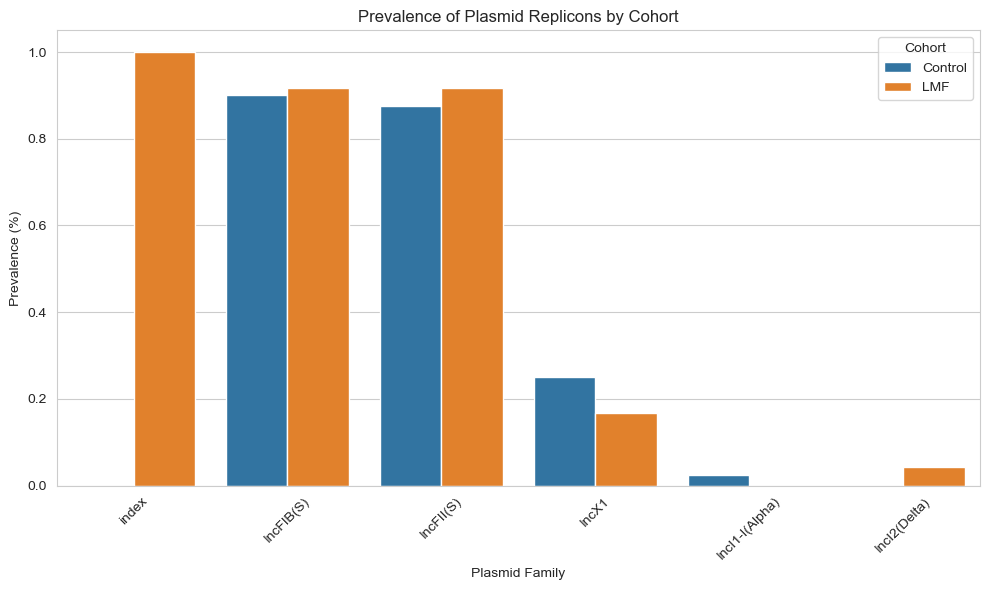

In [103]:
# 5. Visualization
# Prepare data for plotting
plot_df = prevalence.reset_index().melt(id_vars='Cohort', var_name='Plasmid', value_name='Prevalence')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Plasmid', y='Prevalence', hue='Cohort')
plt.title('Prevalence of Plasmid Replicons by Cohort')
plt.ylabel('Prevalence (%)')
plt.xlabel('Plasmid Family')
plt.xticks(rotation=45)
plt.legend(title='Cohort')
plt.tight_layout()
plt.savefig('plasmid_prevalence_barplot.tiff', dpi=600)

In [39]:
# Check IncX1 distribution by SNP cluster
incx1_cluster = merged_df[merged_df['IncX1'] == 1].groupby(['SNP cluster', 'Cohort']).size().unstack(fill_value=0)
print("\nIncX1 distribution by SNP cluster:")
print(incx1_cluster)


IncX1 distribution by SNP cluster:
Cohort            Control  LMF
SNP cluster                   
PDS000026860.270        3    0
PDS000026869.554        3    1
PDS000026945.72         2    2
PDS000084711.573        0    1
PDS000184417.155        2    0


In [41]:
# Check total isolates per cluster in the final set
cluster_counts = merged_df.groupby(['SNP cluster', 'Cohort']).size().unstack(fill_value=0)
print("\nTotal isolates per cluster in final set:")
print(cluster_counts)


Total isolates per cluster in final set:
Cohort             Control  LMF
SNP cluster                    
PDS000002770.694         2    3
PDS000026860.270         3    1
PDS000026869.554         3    1
PDS000026945.72          3    2
PDS000043097.1           1    1
PDS000058525.21          1    1
PDS000065758.1669        7    3
PDS000084711.573         1    1
PDS000184417.155         4    2
PDS000218745.3          15    9


In [43]:
# Calculate cluster-wise IncX1 frequency
incx1_freq = (incx1_cluster / cluster_counts).fillna(0)
print("\nIncX1 frequency by cluster:")
print(incx1_freq)


IncX1 frequency by cluster:
Cohort              Control  LMF
SNP cluster                     
PDS000002770.694   0.000000  0.0
PDS000026860.270   1.000000  0.0
PDS000026869.554   1.000000  1.0
PDS000026945.72    0.666667  1.0
PDS000043097.1     0.000000  0.0
PDS000058525.21    0.000000  0.0
PDS000065758.1669  0.000000  0.0
PDS000084711.573   0.000000  1.0
PDS000184417.155   0.500000  0.0
PDS000218745.3     0.000000  0.0


In [45]:
# Save the merged analysis for the user
merged_df.to_csv('plasmid_analysis_merged.csv', index=False)
stats_df.to_csv('plasmid_stats_results.csv', index=False)

In [49]:
# Load the merged data from previous step (or recreate it)
# I have plasmid_analysis_merged.csv from the previous run.
df = pd.read_csv('plasmid_analysis_merged.csv')

In [51]:
df

,Unnamed: 0,Assembly,SNP cluster,Isolation source,Isolation type,Create date,dataset_source,Computed_serotype,is_LMF,cluster_status,Sample,IncFIB(S),IncFII(S),IncI1-I(Alpha),IncI2(Delta),IncX1,Cohort
0,0,GCA_008003705.1,PDS000026945.72,sichuan pepper,environmental/other,2013-11-20T06:41:47Z,LMF_file,Enteritidis,1,mixed,GCA_008003705.1,1,1,0,0,1,LMF
1,1,GCA_011084405.1,PDS000065758.1669,spice mixture for lahori fish,environmental/other,2015-02-11T00:08:14Z,LMF_file,Enteritidis,1,mixed,GCA_011084405.1,1,1,0,0,0,LMF
2,7,GCA_008025695.1,PDS000184417.155,thyme leaves,environmental/other,2015-02-10T18:10:34Z,LMF_file,Enteritidis,1,mixed,GCA_008025695.1,1,1,0,0,0,LMF
3,9,GCA_008005975.1,PDS000026860.270,feed,environmental/other,2015-02-10T17:09:49Z,LMF_file,Enteritidis,1,mixed,GCA_008005975.1,1,1,0,0,0,LMF
4,12,GCA_008116765.1,PDS000026869.554,pet treat chicken breast strip,environmental/other,2015-07-06T13:16:26Z,LMF_file,Enteritidis,1,mixed,GCA_008116765.1,0,0,0,0,1,LMF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2884,GCA_037003745.1,PDS000026945.72,chicken (food),NaN,2024-03-05T06:11:13Z,Control_file,Enteritidis,0,mixed,GCA_037003745.1,1,1,0,0,1,Control
60,2890,GCA_037003885.1,PDS000026869.554,chicken (food),NaN,2024-03-05T06:12:26Z,Control_file,Enteritidis,0,mixed,GCA_037003885.1,0,0,0,0,1,Control
61,2917,GCA_041411215.1,PDS000184417.155,Chicken meat,environmental/other,2024-08-21T17:24:43Z,Control_file,Enteritidis,0,mixed,GCA_041411215.1,1,1,0,0,1,Control
62,2919,GCA_045376435.1,PDS000026869.554,egg white,environmental/other,2024-11-27T04:04:51Z,Control_file,Enteritidis,0,mixed,GCA_045376435.1,1,1,0,0,1,Control


C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_17352\1025968725.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


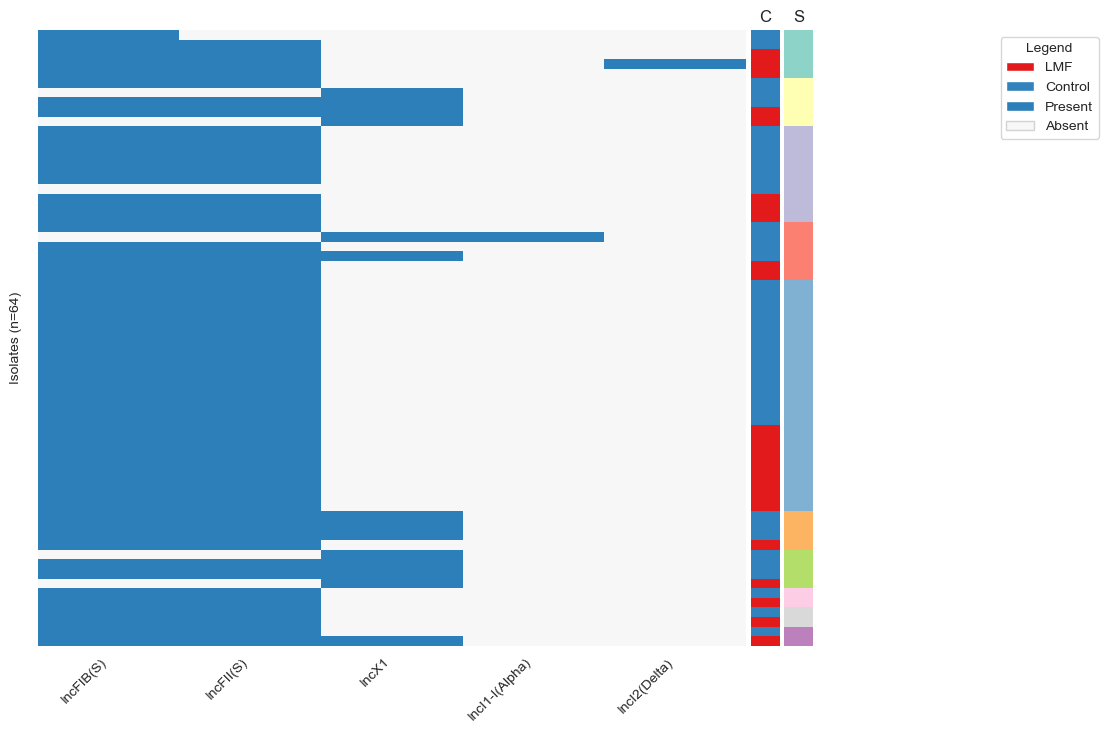

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from statsmodels.stats.contingency_tables import StratifiedTable

# 1. SETUP DATA
df = pd.read_csv('plasmid_analysis_merged.csv')
plasmid_long = pd.read_csv('plasmidfinder_replicons_long.tsv', sep='\t')
plasmid_cols = ['IncFIB(S)', 'IncFII(S)', 'IncX1', 'IncI1-I(Alpha)', 'IncI2(Delta)']
cohort_palette = {'LMF': '#e31a1c', 'Control': '#3182bd'}
presence_color = '#2c7fb8'
absence_color = '#f7f7f7'

# Re-identifying High-Tier clusters
lmf_counts = df[df['Cohort'] == 'LMF'].groupby('SNP cluster').size()
high_tier_clusters = lmf_counts[lmf_counts >= 2].index.tolist()
df['is_high_tier'] = df['SNP cluster'].isin(high_tier_clusters)

# 2. FIGURE 1: HEATMAP (Refining labels)
df_sorted = df.sort_values(['is_high_tier', 'SNP cluster', 'Cohort'], ascending=[False, True, True]).reset_index(drop=True)

fig, (ax_main, ax_cohort, ax_cluster) = plt.subplots(1, 3, figsize=(10, 8), 
                                                     gridspec_kw={'width_ratios': [10, 0.4, 0.4], 'wspace': 0.02})
cmap = mcolors.ListedColormap([absence_color, presence_color])
sns.heatmap(df_sorted[plasmid_cols], ax=ax_main, cmap=cmap, cbar=False, linewidths=0)
ax_main.set_yticklabels([]); ax_main.set_ylabel(f"Isolates (n={len(df_sorted)})"); 
ax_main.set_xticklabels(plasmid_cols, rotation=45, ha='right')

cohort_rgb = [mcolors.to_rgb(cohort_palette[c]) for c in df_sorted['Cohort']]
ax_cohort.imshow(np.array(cohort_rgb).reshape(-1, 1, 3), aspect='auto'); ax_cohort.axis('off'); ax_cohort.set_title("C")

cluster_ids, _ = pd.factorize(df_sorted['SNP cluster'])
cluster_palette = sns.color_palette("Set3", len(np.unique(cluster_ids)))
cluster_rgb = [cluster_palette[i] for i in cluster_ids]
ax_cluster.imshow(np.array(cluster_rgb).reshape(-1, 1, 3), aspect='auto'); ax_cluster.axis('off'); ax_cluster.set_title("S")

legend_elements = [Patch(facecolor=cohort_palette['LMF'], label='LMF'), Patch(facecolor=cohort_palette['Control'], label='Control'),
                   Patch(facecolor=presence_color, label='Present'), Patch(facecolor=absence_color, label='Absent', edgecolor='lightgray')]
ax_main.legend(handles=legend_elements, bbox_to_anchor=(1.35, 1), loc='upper left', title="Legend")
plt.tight_layout()
plt.savefig('Figure_1_Heatmap.png', dpi=300, bbox_inches='tight')


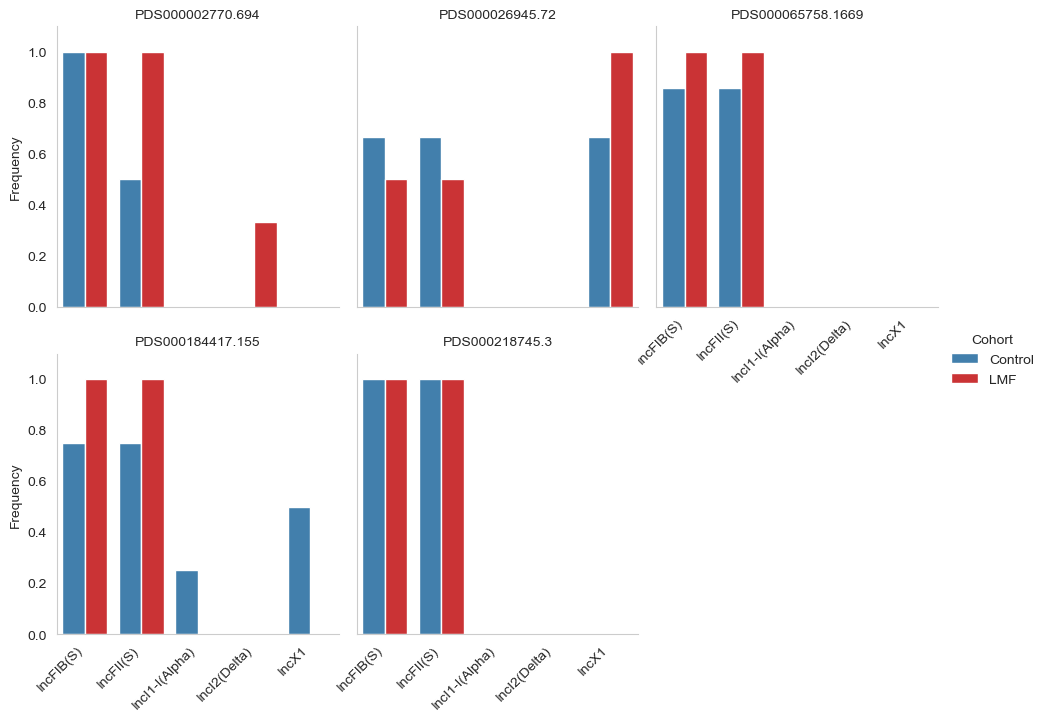

In [111]:
# 3. FIGURE 2: INTRA-CLUSTER FREQUENCY (Fixing cut-off labels)
ht_df = df[df['is_high_tier']].copy()
ht_melt = ht_df.melt(id_vars=['SNP cluster', 'Cohort'], value_vars=plasmid_cols, var_name='Plasmid', value_name='Presence')
cluster_prev = ht_melt.groupby(['SNP cluster', 'Cohort', 'Plasmid'])['Presence'].mean().reset_index()

# Use standard catplot but adjust figure afterwards
g = sns.catplot(data=cluster_prev, x='Plasmid', y='Presence', hue='Cohort', col='SNP cluster', 
                kind='bar', palette=cohort_palette, height=4, aspect=0.8, col_wrap=3)
g.set_axis_labels("", "Frequency")
g.set_titles("{col_name}")
g.set(ylim=(0, 1.1))

# Rotate labels and adjust layout to prevent clipping
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(False)

# This is critical for catplot/FacetGrid to prevent x-label cutoff
g.fig.subplots_adjust(bottom=0.2) 
g.savefig('Figure_2_HighTierFrequency.tiff', dpi=600, bbox_inches='tight')

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_17352\2873512077.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_ready = ht_alleles.groupby(['SNP cluster', 'Cohort', 'PlasmidFamily'])['RepliconAllele'].first().unstack(fill_value='-').applymap(lambda x: x.split('__')[0] if x != '-' else '-')


Figures regenerated with fixed label margins.


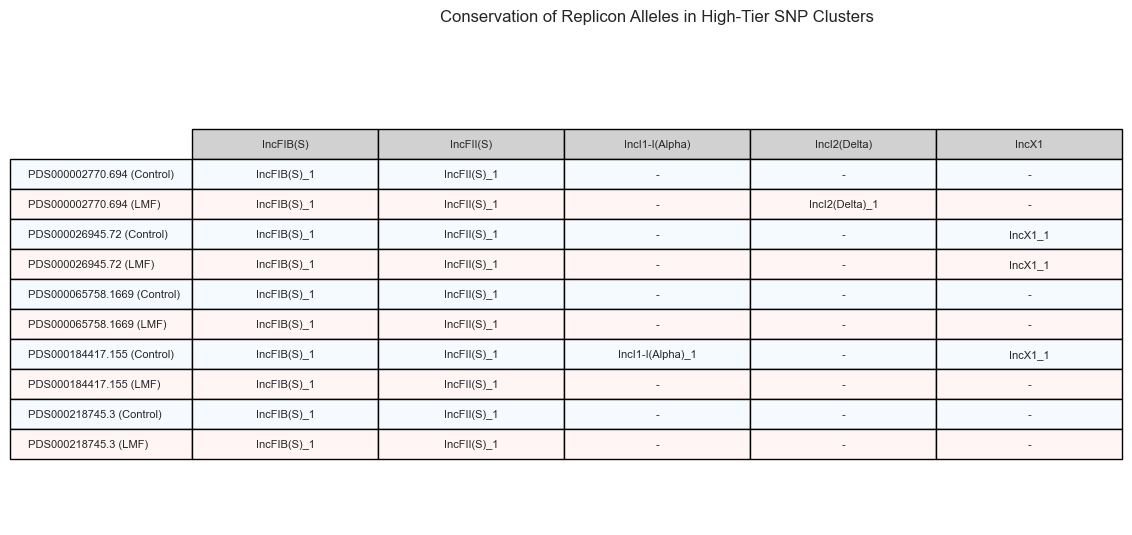

In [113]:
# 4. FIGURE 3: ALLELE CONSISTENCY (Refining)
allele_data = pd.merge(plasmid_long, df[['Assembly', 'SNP cluster', 'Cohort']], left_on='Sample', right_on='Assembly')
ht_alleles = allele_data[allele_data['SNP cluster'].isin(high_tier_clusters)]
plot_ready = ht_alleles.groupby(['SNP cluster', 'Cohort', 'PlasmidFamily'])['RepliconAllele'].first().unstack(fill_value='-').applymap(lambda x: x.split('__')[0] if x != '-' else '-')

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
the_table = ax.table(cellText=plot_ready.values, 
                      rowLabels=[f"{idx[0]} ({idx[1]})" for idx in plot_ready.index], 
                      colLabels=plot_ready.columns, 
                      cellLoc='center', loc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(8)
the_table.scale(1.0, 1.8)

for (row, col), cell in the_table.get_celld().items():
    if row == 0: cell.set_facecolor('#d1d1d1')
    elif row > 0: 
        lbl_cell = the_table.get_celld().get((row, -1))
        if lbl_cell:
            lbl = lbl_cell.get_text().get_text()
            cell.set_facecolor('#fff5f5' if '(LMF)' in lbl else '#f5faff')

plt.title("Conservation of Replicon Alleles in High-Tier SNP Clusters", pad=30)
plt.savefig('Figure_3_AlleleTable.tiff', bbox_inches='tight', dpi=600)

print("Figures regenerated with fixed label margins.")

In [95]:
# Load the files
metadata = pd.read_csv('../../old/Final_65.csv')
plasmid_wide = pd.read_csv('plasmidfinder_replicons_wide.tsv', sep='\t')
plasmid_long = pd.read_csv('plasmidfinder_replicons_long.tsv', sep='\t')
plasmid_summary = pd.read_csv('plasmidfinder_summary.tsv', sep='\t')

In [101]:
import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import StratifiedTable

# Filter metadata
df = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
df = pd.merge(df, plasmid_wide, left_on='Assembly', right_on='Sample', how='left')
df['Cohort'] = df['is_LMF'].map({1: 'LMF', 0: 'Control'})

# Plasmid columns to test
plasmid_cols = ['IncFIB(S)', 'IncFII(S)', 'IncX1']
cmh_results = []

for p in plasmid_cols:
    mixed_clusters = df.groupby('SNP cluster')['Cohort'].nunique()
    valid_clusters = mixed_clusters[mixed_clusters == 2].index
    sub_df = df[df['SNP cluster'].isin(valid_clusters)]
    
    tables = []
    for cluster in valid_clusters:
        cluster_data = sub_df[sub_df['SNP cluster'] == cluster]
        tab = pd.crosstab(cluster_data['Cohort'], cluster_data[p])
        for val in [0, 1]:
            if val not in tab.columns: tab[val] = 0
        for cohort in ['LMF', 'Control']:
            if cohort not in tab.index: tab.loc[cohort] = [0, 0]
        
        tab_2x2 = tab.loc[['LMF', 'Control'], [1, 0]].values
        tables.append(tab_2x2)
    
    # StratifiedTable wants 2 x 2 x K
    # Our 'tables' list is currently list of 2x2. Stack them along a new 3rd axis.
    stratified_data = np.stack(tables, axis=2)
    
    try:
        st = StratifiedTable(stratified_data)
        res = st.test_null_odds()
        cmh_results.append({
            'Plasmid': p,
            'CMH P-value': res.pvalue,
            'Common Odds Ratio': st.oddsratio_pooled,
            'Clusters Included': len(valid_clusters)
        })
    except:
        # Handle cases with zero variance
        cmh_results.append({
            'Plasmid': p,
            'CMH P-value': np.nan,
            'Common Odds Ratio': np.nan,
            'Clusters Included': len(valid_clusters)
        })

cmh_df = pd.DataFrame(cmh_results)

# Allele level analysis
allele_data = pd.merge(plasmid_long, df[['Assembly', 'SNP cluster', 'Cohort']], left_on='Sample', right_on='Assembly')

# Check alleles within High-Tier clusters
lmf_counts = df[df['Cohort'] == 'LMF'].groupby('SNP cluster').size()
high_tier_clusters = lmf_counts[lmf_counts >= 2].index.tolist()

ht_alleles = allele_data[allele_data['SNP cluster'].isin(high_tier_clusters)]
allele_summary = ht_alleles.groupby(['SNP cluster', 'PlasmidFamily', 'RepliconAllele', 'Cohort']).size().unstack(fill_value=0)

print("CMH Test Results:")
print(cmh_df)
print("\nAllele Summary in High-Tier Clusters:")
print(allele_summary.head(20))

# cmh_df.to_csv('plasmid_cmh_results.csv', index=False)
# allele_summary.to_csv('plasmid_allele_summary_ht.csv')

CMH Test Results:
     Plasmid  CMH P-value  Common Odds Ratio  Clusters Included
0  IncFIB(S)     0.947933           0.925926                 10
1  IncFII(S)     0.637644           1.592593                 10
2      IncX1     0.611220           0.635294                 10

Allele Summary in High-Tier Clusters:
Cohort                                                       Control  LMF
SNP cluster       PlasmidFamily  RepliconAllele                          
PDS000002770.694  IncFIB(S)      IncFIB(S)_1__FN432031             2    3
                  IncFII(S)      IncFII(S)_1__CP000858             1    3
                  IncI2(Delta)   IncI2(Delta)_1__AP002527          0    1
PDS000026945.72   IncFIB(S)      IncFIB(S)_1__FN432031             2    1
                  IncFII(S)      IncFII(S)_1__CP000858             2    1
                  IncX1          IncX1_1__EU370913                 2    2
PDS000065758.1669 IncFIB(S)      IncFIB(S)_1__FN432031             6    3
                  Inc

C:\Users\Kinley Tenzin\AppData\Local\Temp\ipykernel_17352\1785918479.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_ready_short = plot_ready.applymap(shorten_allele)


Allele consistency table generated.


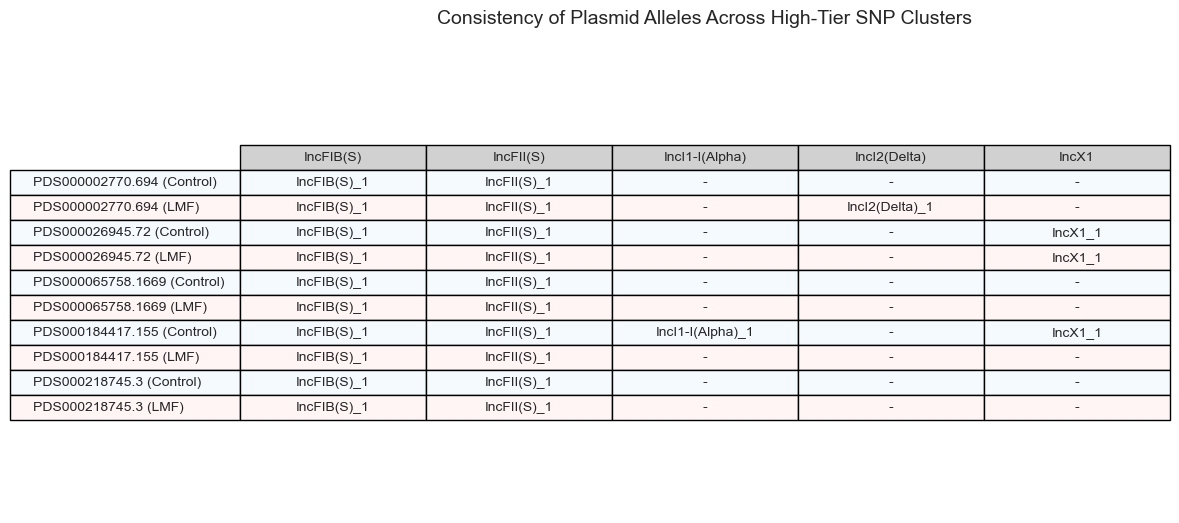

In [105]:
df = metadata[metadata['Assembly'] != 'GCA_037003325.1'].copy()
df['Cohort'] = df['is_LMF'].map({1: 'LMF', 0: 'Control'})

# Identify High-Tier clusters (LMF >= 2)
lmf_counts = df[df['Cohort'] == 'LMF'].groupby('SNP cluster').size()
high_tier_clusters = lmf_counts[lmf_counts >= 2].index.tolist()

# Merge long format with cluster info
allele_data = pd.merge(plasmid_long, df[['Assembly', 'SNP cluster', 'Cohort']], left_on='Sample', right_on='Assembly')
ht_alleles = allele_data[allele_data['SNP cluster'].isin(high_tier_clusters)]

# Create a simplified allele summary
# We want: Cluster | Replicon | Cohort | Allele
# Since alleles are identical within cohort/cluster, we just take the first one
summary = ht_alleles.groupby(['SNP cluster', 'PlasmidFamily', 'Cohort'])['RepliconAllele'].first().unstack(fill_value="Absent")

# Re-format for a nice table/figure
# Let's pivot so Replicons are columns and (Cluster, Cohort) are rows
plot_ready = ht_alleles.groupby(['SNP cluster', 'Cohort', 'PlasmidFamily'])['RepliconAllele'].first().unstack(fill_value='-')

# Clean up allele names for the plot (remove the accession suffix if it's long)
def shorten_allele(x):
    if x == '-': return '-'
    parts = x.split('__')
    return parts[0] if len(parts) > 1 else x

plot_ready_short = plot_ready.applymap(shorten_allele)

# Visualization: A clean table-like figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Plot as a table
the_table = ax.table(cellText=plot_ready_short.values,
                      rowLabels=[f"{idx[0]} ({idx[1]})" for idx in plot_ready_short.index],
                      colLabels=plot_ready_short.columns,
                      cellLoc='center',
                      loc='center',
                      cellColours=None)

# Style the table
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.5)

# Color the rows by cohort
for (row, col), cell in the_table.get_celld().items():
    if row == 0: # Header
        cell.set_facecolor('#d1d1d1')
    elif row > 0:
        # Check cohort in the label
        label = the_table.get_celld()[(row, -1)].get_text().get_text()
        if '(LMF)' in label:
            cell.set_facecolor('#fff5f5')
        else:
            cell.set_facecolor('#f5faff')

plt.title("Consistency of Plasmid Alleles Across High-Tier SNP Clusters", fontsize=14, pad=20)
plt.savefig('plasmid_allele_consistency_table.tiff', bbox_inches='tight', dpi=600)

# Save the raw data for the user
plot_ready_short.to_csv('plasmid_allele_consistency_data.csv')
print("Allele consistency table generated.")